# Plots for the paper

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.io import read
import matplotlib.pylab as pylab
from ase.units import kB

size=24
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [2]:
# get minima structure configurations
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plot_energy_surface
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

# load adaptive simulations
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data
from flonacomldft.utils.diagnostics import avg_windows

ag6_is0 = get_molecule_isomer_minima(name="is0")
ag6_is1 = get_molecule_isomer_minima(name="is1")

ag6_is0.center()
ag6_is1.center()

ag6_is0.translate([4, 0, 0])
ag6_is1.translate([11, 7, 7])

In [3]:
# 300 K results
# path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
# simulations = ["results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl",
#               "results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl"]

# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [4]:
def cvs_from_adaptive(adaptive, isomer_id=0, etype='dft'):

    coord_mapping = Coordinates_mapping(etype='dft')

    xs = torch.cat(adaptive['xs']).detach()

    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = torch.cat(adaptive['isomers']).reshape(-1, 1)

    xs_is0 = []

    for isomer, x in zip(isomers_mask, xs_flatten):

        if (isomer[0]==isomer_id).item():
            xs_is0.append(x)

    xs_is0 = torch.stack(xs_is0) 

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=isomer_id)

    return cvs_is0

In [5]:
def load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer=None):

    ag6_proposals = []
    for chain in range(n_chains):
        for step in range(n_steps):
            try:
            #print("ag6_{:d}_{:d}_{:d}.out".format(n_run, step, chain))
                ag6_proposals.append(read("{:s}DFTAdaptive/ag6_{:d}_{:d}_{:d}.out".format(path, n_run, step, chain)))
            except:
                continue
    coord_mapping = Coordinates_mapping()

    zmat = coord_mapping.get_internal_from_trajectory(ag6_proposals, isomer=isomer, temperature=300)
    xs = coord_mapping.get_real_centered_from_internal(zmat[:, :12], isomer=isomer, energies=zmat[:, 12])        
    
    return xs, zmat, ag6_proposals

def get_participation_ratio_from_dft_proposals(xs, us, model, kB, T):
    
    n_prop = xs.shape[0]
    
    log_weight = -us.squeeze()/(kB*T) + model.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0)
    
    return torch.exp(-log_ratio) / n_prop 

def compute_part_ratios_per_adaptive(adaptive, path, isomer):

    part_ratios = []

    n_runs = adaptive["args"]["n_runs"]
    n_chains = adaptive["args"]["n_runs"]
    n_steps = adaptive["args"]["n_steps"]

    for n_run in range(n_runs):
    
        model = adaptive["dict_flows_training"][n_run][0]['model']
        xs = load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer)[0]

        part_ratio = get_participation_ratio_from_dft_proposals(xs[0].float(), xs[2].float(), model, kB, 300)
    
        part_ratios.append(part_ratio)
        
    mcmc_steps = list(range(0, n_runs*n_steps, n_steps))
        
    return torch.stack(part_ratios), mcmc_steps

## Adaptive one isomer.

In [6]:
keys = ['DFT only', 'DFT+NP']
color_keys = dict(zip(keys, ['blue', 'orange']))
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}
adaptives_is1 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[1], adaptive_mlp_path[1]])}

In [7]:
accs = {key: torch.cat(adaptives_is0[key]['accs']).mean(axis=1) for key in keys}
us = {key: torch.cat(adaptives_is0[key]['us']) for key in keys}
energies = {key: us[key].flatten().detach().numpy() for key in keys}
xs = {key: torch.cat(adaptives_is0[key]['xs']) for key in keys}

In [8]:
cvs = {key: cvs_from_adaptive(adaptives_is0[key]) for key in adaptives_is0.keys()}

In [9]:
part_ratios = {key: compute_part_ratios_per_adaptive(adaptives_is0[key], path + '/' + adaptive_path[:-34], 0) for key, adaptive_path in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}

In [10]:
key = keys[-1]
adaptive_path = adaptive_mlp_path[0]
part_ratios[key] = compute_part_ratios_per_adaptive(adaptives_is0[key], path + '/' + adaptive_path[:-34], 0)

In [11]:
n_start = 500
flow_models = {key: adaptives_is0[key]["dict_flows_training"][-2][0]["model"] for key in adaptives_is0.keys()}

nlls = {key: torch.cat([flow_models[key].nll(xs[key][i, :]) for i in range(n_start, 600)]) for key in adaptives_is0.keys()}

#nlls = {key: flow_models[key].nll(xs[key][n_start, :])  for key in adaptives_is0.keys()}

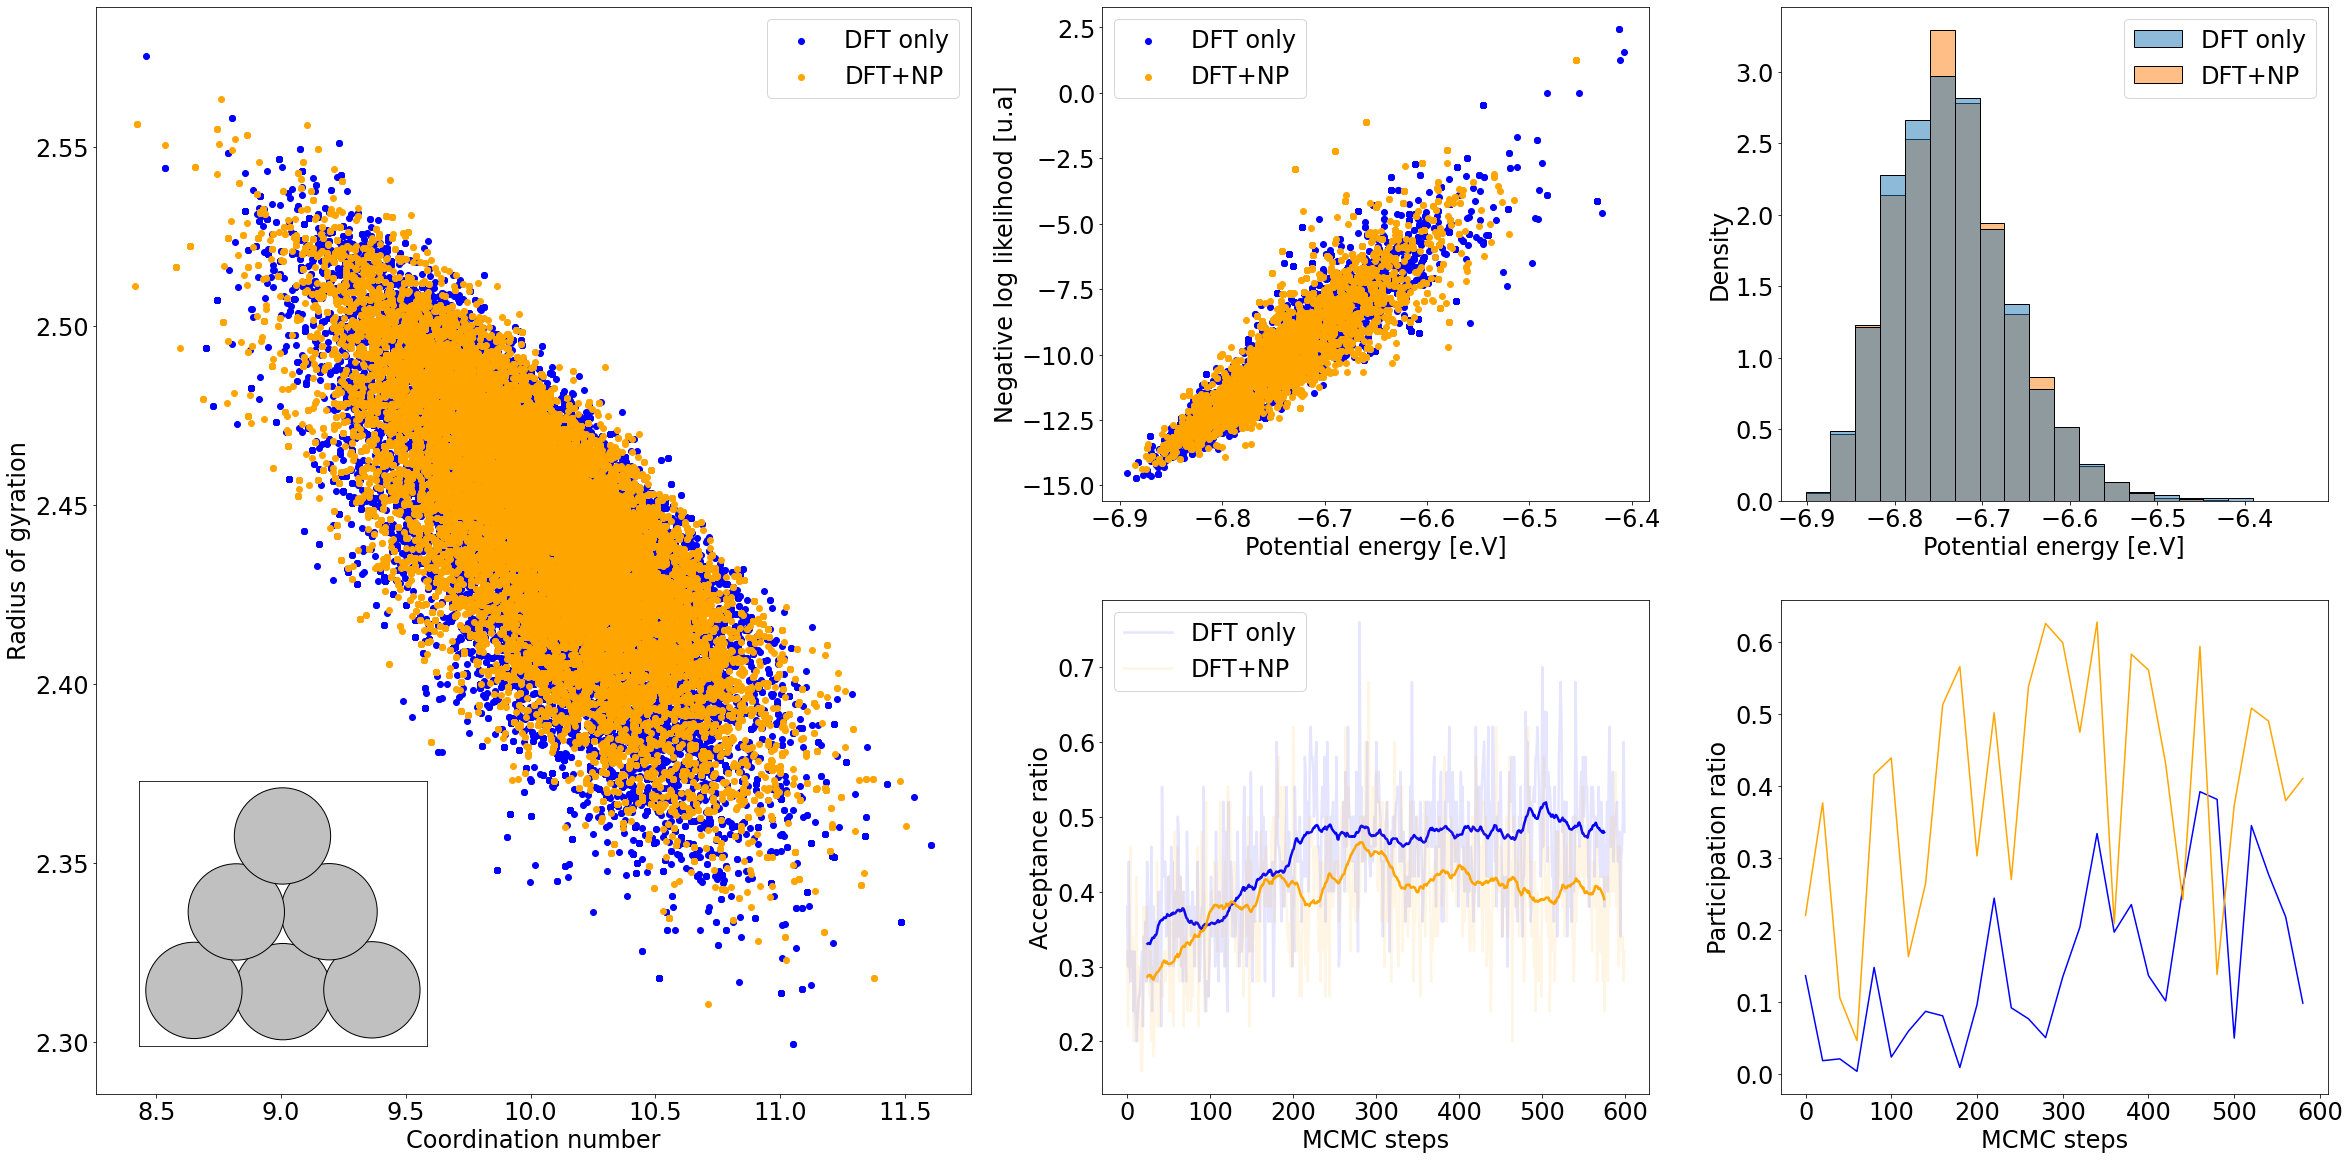

In [12]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(40, 20), gridspec_kw={'width_ratios': [1.6, 1, 1]})
gs = axs[0, 0].get_gridspec()
# remove the underlying axes
for ax in axs[0:, 0]:
    ax.remove()
    
    
axbig = fig.add_subplot(gs[0:, :1])
#axbig.annotate('Big Axes \nGridSpec[1:, -1]', (0.1, 0.5),
               #xycoords='axes fraction', va='center')

#plot_energy_surface(fig=fig, ax=axbig)
for key in keys:
    axbig.scatter(cvs[key][:, 0].detach().numpy(), cvs[key][:, 1].detach().numpy(), c=color_keys[key], label=key)

axbig.set_xlabel('Coordination number')
axbig.set_ylabel('Radius of gyration')

axbig.legend()

l, b, h, w = .14, .15, .2, .1
ax2 = fig.add_axes([l, b, w, h])
plot_atoms(ag6_is0, ax=ax2)
ax2.set_xticks([])
ax2.set_yticks([])

#====

for key in keys:
    axs[0][1].scatter(us[key][n_start:, :].flatten().detach().numpy(), nlls[key].detach(), c=color_keys[key], label=key)

axs[0][1].set_ylabel("Negative log likelihood [u.a]")
axs[0][1].set_xlabel("Potential energy [e.V]")
axs[0][1].legend()

#====

sns.histplot(energies, ax=axs[0][2], kde=False, stat="density", color=color_keys, bins=20)
axs[0][2].set_xlabel("Potential energy [e.V]")

#====

for key in accs.keys():
    set_plot_sequential_data(accs[key], 
                             avg=True, 
                             window_size=50, 
                             color=color_keys[key], 
                             ax=axs[1][1], 
                             linewidth=2.5, 
                             alpha=0.1,
                             label=key)

axs[1][1].legend()
axs[1][1].set_ylabel("Acceptance ratio")
axs[1][1].set_xlabel("MCMC steps")

#====

axs[1][2].set_ylabel("Participation ratio")
axs[1][2].set_xlabel("MCMC steps")

for key in part_ratios.keys():
    axs[1][2].plot(part_ratios[key][1], part_ratios[key][0].detach().numpy(), color=color_keys[key], label=key)

# Add title

In [13]:
accs = {key: torch.cat(adaptives_is1[key]['accs']).mean(axis=1) for key in keys}
us = {key: torch.cat(adaptives_is1[key]['us']) for key in keys}
energies = {key: us[key].flatten().detach().numpy() for key in keys}
xs = {key: torch.cat(adaptives_is1[key]['xs']) for key in keys}

In [14]:
len(adaptives_mlp[1]['dict_flows_training'][-2])

2

In [15]:
cvs = {key: cvs_from_adaptive(adaptives_is1[key], isomer_id=1) for key in adaptives_is1.keys()}

In [16]:
n_start = 500
flow_models = {key: adaptives_is1[key]["dict_flows_training"][-2][0]["model"] for key in adaptives_is1.keys()}

nlls = {key: torch.cat([flow_models[key].nll(xs[key][i, :]) for i in range(n_start, 600)]) for key in adaptives_is1.keys()}

#nlls = {key: flow_models[key].nll(xs[key][n_start, :])  for key in adaptives_is0.keys()}

In [ ]:
def plot_figure_1():

    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(40, 20), gridspec_kw={'width_ratios': [1.6, 1, 1]})
    gs = axs[0, 0].get_gridspec()

    for ax in axs[0:, 0]:
    ax.remove()
    
    
    axbig = fig.add_subplot(gs[0:, :1])
    #axbig.annotate('Big Axes \nGridSpec[1:, -1]', (0.1, 0.5),
                   #xycoords='axes fraction', va='center')
    
    #plot_energy_surface(fig=fig, ax=axbig)
    for key in keys:
        axbig.scatter(cvs[key][:, 0].detach().numpy(), cvs[key][:, 1].detach().numpy(), c=color_keys[key], label=key)
    
    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')
    
    axbig.legend()
    
    l, b, h, w = .14, .15, .2, .1
    ax2 = fig.add_axes([l, b, w, h])
    plot_atoms(ag6_is1, ax=ax2)
    ax2.set_xticks([])
    ax2.set_yticks([])




Text(0.5, 0, 'MCMC steps')

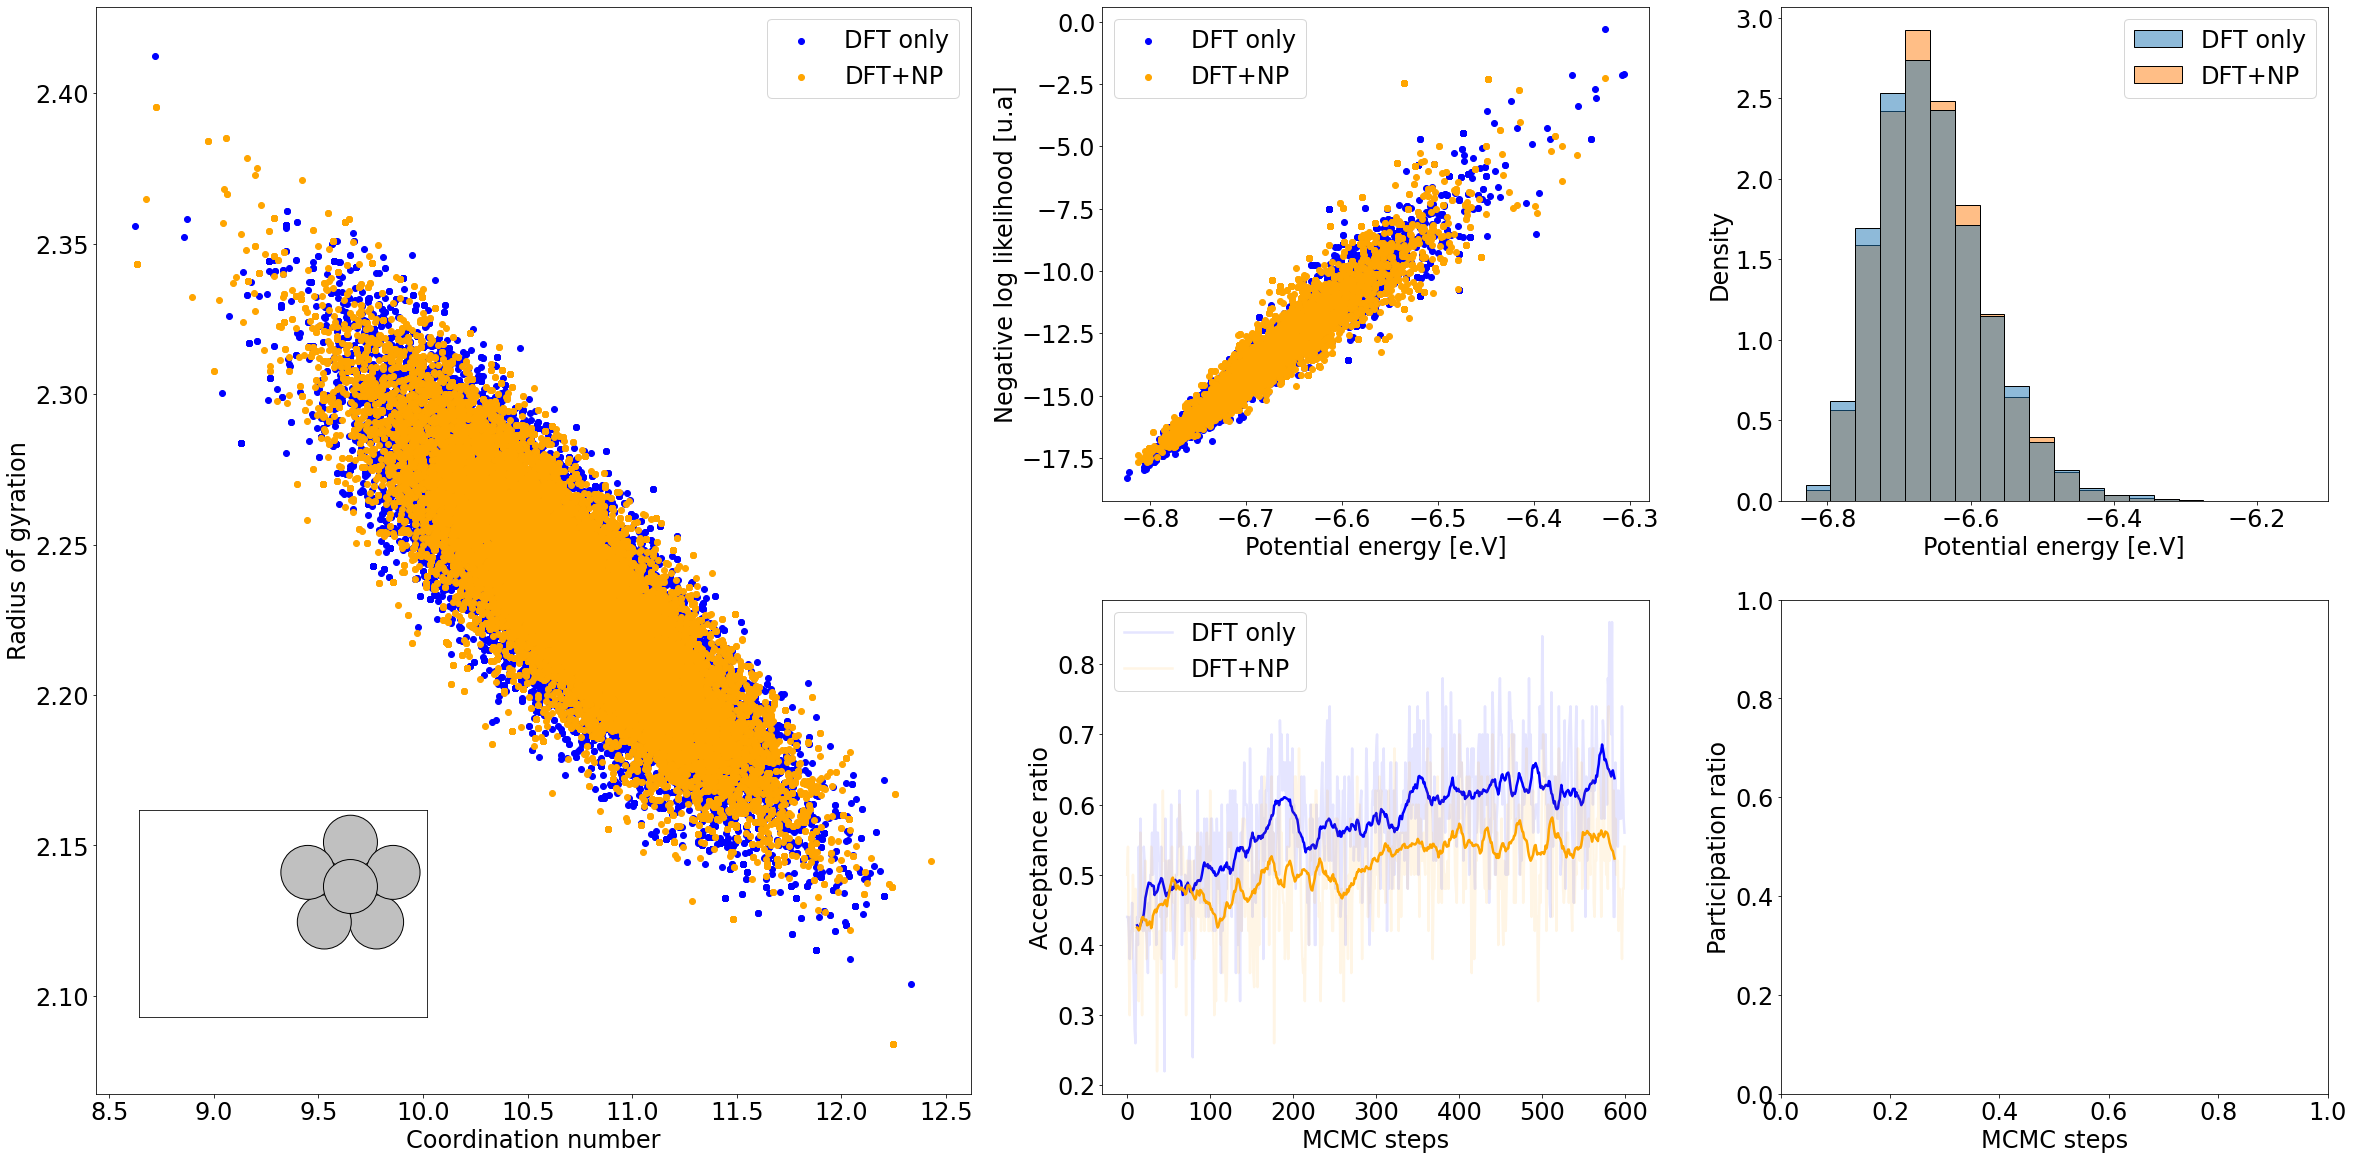

In [17]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(40, 20), gridspec_kw={'width_ratios': [1.6, 1, 1]})
gs = axs[0, 0].get_gridspec()
# remove the underlying axes
for ax in axs[0:, 0]:
    ax.remove()
    
    
axbig = fig.add_subplot(gs[0:, :1])
#axbig.annotate('Big Axes \nGridSpec[1:, -1]', (0.1, 0.5),
               #xycoords='axes fraction', va='center')

#plot_energy_surface(fig=fig, ax=axbig)
for key in keys:
    axbig.scatter(cvs[key][:, 0].detach().numpy(), cvs[key][:, 1].detach().numpy(), c=color_keys[key], label=key)

axbig.set_xlabel('Coordination number')
axbig.set_ylabel('Radius of gyration')

axbig.legend()

l, b, h, w = .14, .15, .2, .1
ax2 = fig.add_axes([l, b, w, h])
plot_atoms(ag6_is1, ax=ax2)
ax2.set_xticks([])
ax2.set_yticks([])

#====

for key in keys:
    axs[0][1].scatter(us[key][n_start:, :].flatten().detach().numpy(), nlls[key].detach(), c=color_keys[key], label=key)

axs[0][1].set_ylabel("Negative log likelihood [u.a]")
axs[0][1].set_xlabel("Potential energy [e.V]")
axs[0][1].legend()

#====

sns.histplot(energies, ax=axs[0][2], kde=False, stat="density", color=color_keys, bins=20)
axs[0][2].set_xlabel("Potential energy [e.V]")

#====

for key in accs.keys():
    set_plot_sequential_data(accs[key], 
                             avg=True, 
                             window_size=25, 
                             color=color_keys[key], 
                             ax=axs[1][1], 
                             linewidth=2.5, 
                             alpha=0.1,
                             label=key)

axs[1][1].legend()
axs[1][1].set_ylabel("Acceptance ratio")
axs[1][1].set_xlabel("MCMC steps")

#====

axs[1][2].set_ylabel("Participation ratio")
axs[1][2].set_xlabel("MCMC steps")

#for key in part_ratios.keys():
#    axs[1][2].plot(part_ratios[key][1], part_ratios[key][0].detach().numpy(), color=color_keys[key], label=key)

# Add title

In [18]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl']

# load mcmc results
keys = ['DFT-DFT', 'DFT-MLP', 'MLP-MLP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, path) for mcmc_path, key in zip(mcmc_paths, keys)}